<a href="https://colab.research.google.com/github/Hesam-Ayat/ai_course_exersize/blob/main/Trasnportation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

f = glob.glob("gtfs_rt_*.csv.gz")[0]
print("Processing:", f)

CHUNK_SIZE = 100_000

delay_values_sample = []
hourly_sum, hourly_count = {}, {}
daily_sum, daily_count = {}, {}
line_sum, line_count = {}, {}
stop_sum, stop_count = {}, {}
total_raw, total_clean = 0, 0

reader = pd.read_csv(f, compression="gzip", sep=";", chunksize=CHUNK_SIZE, low_memory=False)

for i, chunk in enumerate(reader):
    total_raw += len(chunk)

    chunk = chunk[
        (chunk["tripupdates_and_gtfs_not_merged_within_service_id"] == "f")
        & (chunk["tripupdates_not_merged_with_stoptimes_or_trip"] == "f")
        & (chunk["TransportMode"] == "BUS")
    ].dropna(subset=["observed_arrival_delay"])

    if len(chunk) == 0:
        continue

    total_clean += len(chunk)

    delay_min = chunk["observed_arrival_delay"] / 60.0
    hour = (chunk["scheduled_arrival_time_sfm"] // 3600) % 24
    dow = pd.to_datetime(chunk["date"].astype(str), format="%Y%m%d", errors="coerce").dt.day_name()

    if len(delay_values_sample) < 500_000:
        n_sample = min(2000, len(delay_min))
        delay_values_sample.extend(delay_min.sample(n_sample, random_state=1).tolist())

    hsum = delay_min.groupby(hour).sum()
    hcnt = delay_min.groupby(hour).count()
    for h in hsum.index:
        hourly_sum[h] = hourly_sum.get(h, 0) + hsum[h]
        hourly_count[h] = hourly_count.get(h, 0) + hcnt[h]

    dsum = delay_min.groupby(dow).sum()
    dcnt = delay_min.groupby(dow).count()
    for d in dsum.index:
        daily_sum[d] = daily_sum.get(d, 0) + dsum[d]
        daily_count[d] = daily_count.get(d, 0) + dcnt[d]

    lsum = delay_min.groupby(chunk["LineNumber"]).sum()
    lcnt = delay_min.groupby(chunk["LineNumber"]).count()
    for l in lsum.index:
        line_sum[l] = line_sum.get(l, 0) + lsum[l]
        line_count[l] = line_count.get(l, 0) + lcnt[l]

    ssum = delay_min.groupby(chunk["observed_stop_id"]).sum()
    scnt = delay_min.groupby(chunk["observed_stop_id"]).count()
    for s in ssum.index:
        stop_sum[s] = stop_sum.get(s, 0) + ssum[s]
        stop_count[s] = stop_count.get(s, 0) + scnt[s]

    del chunk, delay_min
    if i % 10 == 0:
        print("  processed", total_raw, "rows so far...")

print("DONE. Raw:", total_raw, " Clean:", total_clean)

Processing: gtfs_rt_202401.csv.gz
  processed 100000 rows so far...
  processed 1100000 rows so far...
  processed 2100000 rows so far...
  processed 3100000 rows so far...
  processed 4100000 rows so far...
  processed 5100000 rows so far...
  processed 6100000 rows so far...
  processed 7100000 rows so far...
  processed 8100000 rows so far...
  processed 9100000 rows so far...
  processed 10100000 rows so far...
  processed 11100000 rows so far...
  processed 12100000 rows so far...
  processed 13100000 rows so far...
  processed 14100000 rows so far...
  processed 15100000 rows so far...
  processed 16100000 rows so far...
  processed 17100000 rows so far...
  processed 18100000 rows so far...
DONE. Raw: 18659047  Clean: 15591049


stops columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'platform_code']
Stops with enough data: 10538


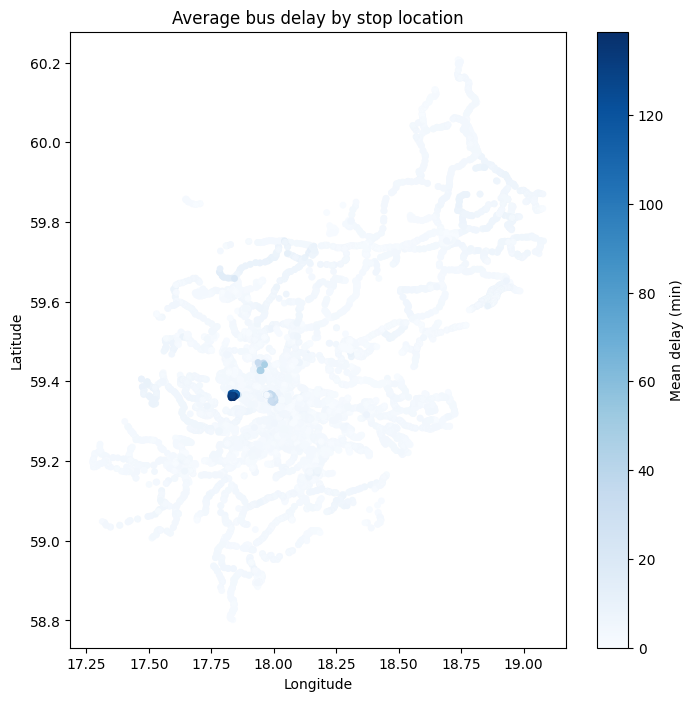


Top 10 worst stops:
                 stop_name  mean_delay_min
10131          Krikongränd       138.74500
10139  Mirabellbacken övre       138.61500
10141        Medsolsbacken       138.46875
10132       Vindruvsbacken       138.30625
10136      Jaktpaviljongen       137.96500
10134       Hässelby kyrka       137.80250
10135       Hässelby kyrka       137.73750
10137      Jaktpaviljongen       137.68875
10138  Mirabellbacken övre       137.65625
10140       Mirabellbacken       137.62375


In [11]:
stops_probe = pd.read_csv("stops.csv", nrows=1)
sep_stops = ";" if stops_probe.shape[1] == 1 else ","
stops = pd.read_csv("stops.csv", sep=sep_stops)
print("stops columns:", stops.columns.tolist())

stop_mean = pd.Series({s: stop_sum[s]/stop_count[s] for s in stop_sum if stop_count[s] >= 20})
stop_df = stop_mean.rename("mean_delay_min").reset_index().rename(columns={"index": "stop_id"})

stop_df = stop_df.merge(stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]], on="stop_id", how="left")
stop_df = stop_df.dropna(subset=["stop_lat", "stop_lon"])

print("Stops with enough data:", len(stop_df))

plt.figure(figsize=(8,8))
sc = plt.scatter(stop_df["stop_lon"], stop_df["stop_lat"],
                  c=stop_df["mean_delay_min"], cmap="Blues", s=15, vmin=0)
plt.colorbar(sc, label="Mean delay (min)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Average bus delay by stop location")
plt.show()

print("\nTop 10 worst stops:")
print(stop_df.sort_values("mean_delay_min", ascending=False)[["stop_name","mean_delay_min"]].head(10))

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(np.clip(delay_values_sample, -10, 30), bins=80, color="#2E5A88", edgecolor="white")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Delay (minutes)"); plt.ylabel("Count")
plt.title("Distribution of bus arrival delay (sampled)")
plt.show()
print("Mean delay (sample):", round(np.mean(delay_values_sample), 2), "min")

hourly_mean = pd.Series({h: hourly_sum[h]/hourly_count[h] for h in hourly_sum}).sort_index()
plt.figure(figsize=(9,5))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o", color="#2E5A88")
plt.xlabel("Hour of day"); plt.ylabel("Mean delay (min)")
plt.title("Average delay by hour of day")
plt.show()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_mean = pd.Series({d: daily_sum[d]/daily_count[d] for d in daily_sum}).reindex(day_order)
plt.figure(figsize=(8,5))
plt.bar(daily_mean.index, daily_mean.values, color="#2E5A88")
plt.xticks(rotation=30, ha="right")
plt.title("Average delay by day of week")
plt.show()

line_mean = pd.Series({l: line_sum[l]/line_count[l] for l in line_sum if line_count[l] >= 50})
print("Top 10 worst lines:")
print(line_mean.sort_values(ascending=False).head(10))

In [13]:
target_stop = suspicious_stops[0]

raw_delays = []
reader2 = pd.read_csv(f, compression="gzip", sep=";", chunksize=100_000, low_memory=False)
for chunk in reader2:
    sub = chunk[chunk["observed_stop_id"] == target_stop]
    if len(sub) > 0:
        raw_delays.extend((sub["observed_arrival_delay"] / 60.0).tolist())

raw_delays = pd.Series(raw_delays)
print("Count:", len(raw_delays))
print("Mean:", raw_delays.mean())
print("Median:", raw_delays.median())
print(raw_delays.describe())
print("\nSample values:", sorted(raw_delays.tolist())[-20:])

Count: 154
Mean: 138.745
Median: 151.325
count     40.000000
mean     138.745000
std       42.062583
min        0.000000
25%      147.345833
50%      151.325000
75%      164.816667
max      166.050000
dtype: float64

Sample values: [nan, nan, nan, nan, 148.65, nan, nan, 150.18333333333334, nan, nan, nan, nan, 26.483333333333334, 143.43333333333334, nan, nan, nan, 93.11666666666666, nan, 45.28333333333333]


In [14]:
raw_check = pd.read_csv(f, compression="gzip", sep=";", nrows=2_000_000)
sample_rows = raw_check[raw_check["observed_stop_id"] == target_stop]
print(sample_rows[[
    "date", "LineNumber", "trip_id",
    "scheduled_arrival_time_sfm", "observed_arrival_time_sfm",
    "observed_arrival_delay",
    "tripupdates_and_gtfs_not_merged_within_service_id",
    "tripupdates_not_merged_with_stoptimes_or_trip"
]].head(10))

/tmp/ipykernel_2205/433052231.py:2: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_check = pd.read_csv(f, compression="gzip", sep=";", nrows=2_000_000)


             date LineNumber            trip_id  scheduled_arrival_time_sfm  \
1059083  20240102        908  14010000645268158                       34568   
1059121  20240102        908  14010000645268235                       38168   
1059159  20240102        908  14010000645268390                       41768   
1059197  20240102        908  14010000645268467                       44468   
1059235  20240102        908  14010000645268725                       51668   
1059273  20240102        908  14010000645268775                       54368   
1059311  20240102        908  14010000645268930                       57968   
1696448  20240103        908  14010000645268158                       34568   
1696486  20240103        908  14010000645268235                       38168   
1696524  20240103        908  14010000645268390                       41768   

         observed_arrival_time_sfm  observed_arrival_delay  \
1059083                    43550.0                  8982.0   
105912

In [15]:
import pandas as pd

daily_weather = pd.read_excel("matdata_Stockholm_2024-01-01_2024-01-31_dygnsmedel.xlsx", sheet_name=0)
daily_weather = daily_weather[["Datum", "Nederbörd (mm)", "Temperatur (°C)", "Vindhastighet (m/s)"]]
daily_weather.columns = ["date", "precip_mm", "temp_c", "wind_ms"]
daily_weather["date"] = pd.to_datetime(daily_weather["date"])
daily_weather.head()

,date,precip_mm,temp_c,wind_ms
0,2024-01-01,0.0,-2.5,4.8
1,2024-01-02,0.2,-5.4,5.2
2,2024-01-03,0.0,-6.9,7.6
3,2024-01-04,0.1,-7.8,4.9
4,2024-01-05,0.0,-9.9,3.5


In [17]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

f = glob.glob("gtfs_rt_*.csv.gz")[0]
print("Processing:", f)

CHUNK_SIZE = 100_000

delay_values_sample = []
hourly_sum, hourly_count = {}, {}
daily_sum, daily_count = {}, {}
line_sum, line_count = {}, {}
stop_sum, stop_count = {}, {}
date_sum, date_count = {}, {}          # <-- جدید
total_raw, total_clean = 0, 0

reader = pd.read_csv(f, compression="gzip", sep=";", chunksize=CHUNK_SIZE, low_memory=False)

for i, chunk in enumerate(reader):
    total_raw += len(chunk)

    chunk = chunk[
        (chunk["tripupdates_and_gtfs_not_merged_within_service_id"] == "f")
        & (chunk["tripupdates_not_merged_with_stoptimes_or_trip"] == "f")
        & (chunk["TransportMode"] == "BUS")
    ].dropna(subset=["observed_arrival_delay"])

    if len(chunk) == 0:
        continue

    total_clean += len(chunk)

    delay_min = chunk["observed_arrival_delay"] / 60.0
    hour = (chunk["scheduled_arrival_time_sfm"] // 3600) % 24
    date_parsed = pd.to_datetime(chunk["date"].astype(str), format="%Y%m%d", errors="coerce")
    dow = date_parsed.dt.day_name()
    date_only = date_parsed.dt.date

    if len(delay_values_sample) < 500_000:
        n_sample = min(2000, len(delay_min))
        delay_values_sample.extend(delay_min.sample(n_sample, random_state=1).tolist())

    hsum = delay_min.groupby(hour).sum(); hcnt = delay_min.groupby(hour).count()
    for h in hsum.index:
        hourly_sum[h] = hourly_sum.get(h, 0) + hsum[h]
        hourly_count[h] = hourly_count.get(h, 0) + hcnt[h]

    dsum = delay_min.groupby(dow).sum(); dcnt = delay_min.groupby(dow).count()
    for d in dsum.index:
        daily_sum[d] = daily_sum.get(d, 0) + dsum[d]
        daily_count[d] = daily_count.get(d, 0) + dcnt[d]

    lsum = delay_min.groupby(chunk["LineNumber"]).sum(); lcnt = delay_min.groupby(chunk["LineNumber"]).count()
    for l in lsum.index:
        line_sum[l] = line_sum.get(l, 0) + lsum[l]
        line_count[l] = line_count.get(l, 0) + lcnt[l]

    ssum = delay_min.groupby(chunk["observed_stop_id"]).sum(); scnt = delay_min.groupby(chunk["observed_stop_id"]).count()
    for s in ssum.index:
        stop_sum[s] = stop_sum.get(s, 0) + ssum[s]
        stop_count[s] = stop_count.get(s, 0) + scnt[s]

    dtsum = delay_min.groupby(date_only).sum(); dtcnt = delay_min.groupby(date_only).count()   # <-- جدید
    for dt in dtsum.index:
        date_sum[dt] = date_sum.get(dt, 0) + dtsum[dt]
        date_count[dt] = date_count.get(dt, 0) + dtcnt[dt]

    del chunk, delay_min
    if i % 10 == 0:
        print("  processed", total_raw, "rows so far...")

print("DONE. Raw:", total_raw, " Clean:", total_clean)

Processing: gtfs_rt_202401.csv.gz
  processed 100000 rows so far...
  processed 1100000 rows so far...
  processed 2100000 rows so far...
  processed 3100000 rows so far...
  processed 4100000 rows so far...
  processed 5100000 rows so far...
  processed 6100000 rows so far...
  processed 7100000 rows so far...
  processed 8100000 rows so far...
  processed 9100000 rows so far...
  processed 10100000 rows so far...
  processed 11100000 rows so far...
  processed 12100000 rows so far...
  processed 13100000 rows so far...
  processed 14100000 rows so far...
  processed 15100000 rows so far...
  processed 16100000 rows so far...
  processed 17100000 rows so far...
  processed 18100000 rows so far...
DONE. Raw: 18659047  Clean: 15591049


         date  precip_mm  temp_c  wind_ms  mean_delay_min
0  2024-01-01        0.0    -2.5      4.8        1.958822
1  2024-01-02        0.2    -5.4      5.2        2.040334
2  2024-01-03        0.0    -6.9      7.6        1.744829
3  2024-01-04        0.1    -7.8      4.9        2.340876
4  2024-01-05        0.0    -9.9      3.5        2.049664
5  2024-01-06        0.0   -11.3      2.3        2.320557
6  2024-01-07        0.0   -11.0      1.2        2.073788
7  2024-01-08        0.0   -10.2      3.1        2.282955
8  2024-01-09        0.0    -2.3      3.9        2.739013
9  2024-01-10        0.0     0.3      3.4        2.409455
10 2024-01-11        0.0     1.3      3.3        2.275366
11 2024-01-12        0.0     1.4      4.6        1.946613
12 2024-01-13        0.0    -0.9      2.7        2.013436
13 2024-01-14        0.1    -2.1      2.5        1.786996
14 2024-01-15        0.1    -5.6      4.6        2.905648
15 2024-01-16        0.0   -12.7      3.2        3.039546
16 2024-01-17 

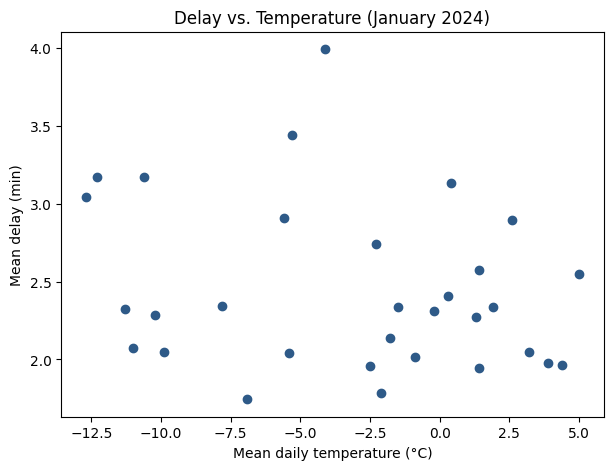

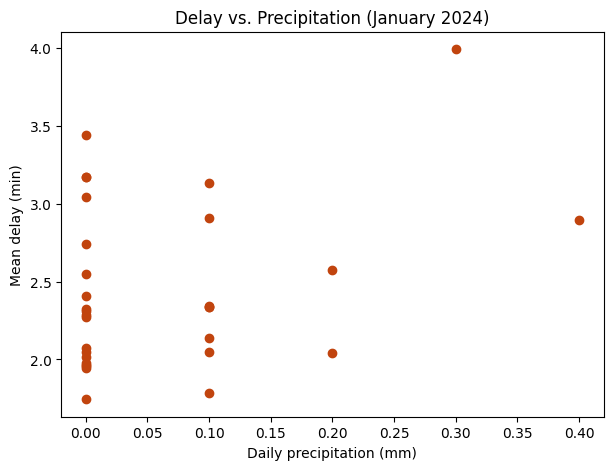

In [18]:
daily_delay = pd.Series({d: date_sum[d]/date_count[d] for d in date_sum})
daily_delay.index = pd.to_datetime(daily_delay.index)
daily_delay = daily_delay.rename("mean_delay_min").reset_index().rename(columns={"index": "date"})

merged = daily_weather.merge(daily_delay, on="date")
print(merged)

print("\nCorrelations with mean delay:")
print(merged[["precip_mm", "temp_c", "wind_ms", "mean_delay_min"]].corr()["mean_delay_min"])

plt.figure(figsize=(7,5))
plt.scatter(merged["temp_c"], merged["mean_delay_min"], color="#2E5A88")
plt.xlabel("Mean daily temperature (°C)"); plt.ylabel("Mean delay (min)")
plt.title("Delay vs. Temperature (January 2024)")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(merged["precip_mm"], merged["mean_delay_min"], color="#C1440E")
plt.xlabel("Daily precipitation (mm)"); plt.ylabel("Mean delay (min)")
plt.title("Delay vs. Precipitation (January 2024)")
plt.show()